## Generalized Linear Model

### Likelihood (transconjugants)

For each experiment \(i\), replica \(j\), within-replica observation \(k\), and condition \(c\),

$$
T_{i,j,k,c}\mid \lambda_{i,j,c},\,X_{i,c},\,\rho_k
\;\overset{\text{ind}}{\sim}\;
\text{Poisson}\!\big(\rho_k\,\lambda_{i,j,c}\big),
$$

with

$$
\lambda_{i,j,c}=\alpha_i\,\theta_{i,j,c}.
$$

### Indices and variables

- \(i \in \{1,\dots,10\}\): experiment  
- \(j \in \{A,B,C\}\): experiment replica  
- \(k \in \{1,\dots,9\}\): observations within each replica  
- \(c \in \{-1,1\}\): control (\(c=-1\)) or treatment (\(c=+1\))  
- \(T_{i,j,k,c}\): transconjugant count  
- \(X_{i,c}\): covariate vector (Temp, \([\mathrm{IBU}]\), \([\mathrm{DMSO}]\)) for experiment \(i\) under condition \(c\)  
- \(\rho_k = 10^{-\lceil k/3\rceil}\): dilution factor for transconjugant measurements  
- \(\alpha_i\): donor count (exposure) for experiment \(i\)  
- \(\theta_{i,j,c}\): transconjugation rate per donor  

---

## Linear predictor (log link)

We model \(\lambda_{i,j,c}\) using a log link with an exposure offset:

$$
\log(\lambda_{i,j,c})
=
\log(\alpha_i)
+ b_{i,j}
+ \boldsymbol{\beta}^{\top}F(\mathbf{x}_{i,c}).
$$

- \(\mathbf{x}_{i,c}\): raw covariates for experiment \(i\), condition \(c\)  
- \(F(\mathbf{x}_{i,c})\): feature map (e.g., main effects, interactions, transformations)  
- \(\boldsymbol{\beta}\in\mathbb{R}^p\): fixed-effect coefficients  

### Random effect (replica-level)

$$
b_{i,j}\mid \sigma_b^2
\;\overset{\text{iid}}{\sim}\;
\mathcal{N}(0,\sigma_b^2).
$$

---

## Bayesian model for donors

### Likelihood (donor measurements)

For donor count measurements indexed by \(k\),

$$
D_{i,k}\mid \alpha_i,\,\delta_k
\;\overset{\text{ind}}{\sim}\;
\text{Poisson}\!\big(\delta_k\,\alpha_i\big),
$$

where

- \(D_{i,k}\): donor count measurement for experiment \(i\)  
- \(\delta_k = 10^{-5-\lceil k/3\rceil}\): dilution factor for donor measurements  

---

## Priors

### Donor-level prior

$$
\log(\alpha_i)\mid \mu_\alpha,\,\sigma_\alpha^2
\;\overset{\text{iid}}{\sim}\;
\mathcal{N}(\mu_\alpha,\sigma_\alpha^2).
$$

### Hyperpriors for donor parameters

$$
\mu_\alpha \sim \mathcal{N}(\mu_{\alpha_0},\sigma_{\alpha_0}^2),
\qquad
\sigma_\alpha \sim \text{half-}\mathcal{N}(0,s_{\alpha_0}).
$$

### Priors for fixed effects

$$
\boldsymbol{\beta}\mid \tau
\sim
\mathcal{N}\!\big(\mathbf{0},\,\tau^2 I_p\big),
\qquad
\tau \sim \text{half-}\mathcal{N}(0,1).
$$

### Prior for random-effect variance

$$
\sigma_b^2 \sim \text{Inverse-Gamma}(2,1).
$$

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions



import os
from pathlib import Path

# Find and navigate to Progetto_Bayesian_Statistics
current = Path.cwd()

# Check if we're already there
if current.name == 'Progetto_Bayesian_Statistics':
    print(f"Already in project root: {current}")
else:
    # Search up to parent directories
    for parent in [current] + list(current.parents):
        if parent.name == 'Progetto_Bayesian_Statistics':
            os.chdir(parent)
            print(f"Changed to: {parent}")
            break
    else:
        raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

# Verify
assert Path('src').exists(), "src/ folder not found"
print(f"Current directory: {os.getcwd()}")
print(f"Contents: {os.listdir()}")


/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Changed to: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
Current directory: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics
Contents: ['.git', '.gitignore', 'requirements.bk.txt', 'README.md', 'data', 'requirements.txt', 'materials', 'src']


In [ ]:


# Create ./stan folder if does not exists
STAN_PATH = "./src/stan_models/"

: 

In [ ]:
import cmdstanpy
print(cmdstanpy.cmdstan_path())

/home/ahbagheri/.cmdstan/cmdstan-2.38.0


: 

In [ ]:
#loading data
#get the data
data=pd.read_csv("./data/data.csv")
data_donors=pd.read_csv("./data/data_donatori.csv")
data=data[data['Conta']!='TMTC']
data_donors=data_donors[data_donors['Conta']!='TMTC']
#Rename columns
data.rename(columns={'Idx Replica Condizione': 'Idx Replica Experiment','Controllo':'Control','Idx Replica Diluizione':'Idx Replica Diluition','Conta':'Count'}, inplace=True)
data_donors.rename(columns={'Idx Replica Diluizione':'Idx Replica Experiment','Conta':'Count'}, inplace=True)

#Modify values in some columns:
#Modify Idx Experiment such that experiments 5 and 6 have the same idx, experiments 7 and 8, experiment 5,6 has the same index as 5 and 6 and experiment 7,8 the same as 7 and 8
#but first convert all to string to avoid problems with mixed types
data['Idx Experiment'] = data['Idx Experiment'].astype(str)
data['Idx Experiment'] = data['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})
#now reconvert to numeric
data['Idx Experiment'] = pd.to_numeric(data['Idx Experiment'])

data_donors['Idx Experiment'] = data_donors['Idx Experiment'].astype(str)
data_donors['Idx Experiment'] = data_donors['Idx Experiment'].replace({'6': '5', '7':'6','8': '6', '9':'7','10':'8','5,6': '5', '7,8':'6'})

#modify control column: convert 'Yes' to 1 and 'No' to 0
data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})



#now reconvert to numeric
data_donors['Idx Experiment'] = pd.to_numeric(data_donors['Idx Experiment'])

print(data['Idx Experiment'].unique())
print(data_donors['Idx Experiment'].unique())

#convert to numeric all the others columns I need 
#convert A;B;C in 1;2;3
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].astype(str)
data['Idx Replica Experiment'] = data['Idx Replica Experiment'].replace({'A': '1', 'B':'2','C': '3'})
#now reconvert to numeric
data['Idx Replica Experiment'] = pd.to_numeric(data['Idx Replica Experiment'])

data['Count'] = pd.to_numeric(data['Count'])
data['Idx Replica Diluition'] = pd.to_numeric(data['Idx Replica Diluition'])
data['Diluition'] = pd.to_numeric(data['Diluition'])
data['IBU'] = pd.to_numeric(data['IBU'])
data['DMSO'] = pd.to_numeric(data['DMSO'])
data['Temp'] = pd.to_numeric(data['Temp'])
data_donors['Count'] = pd.to_numeric(data_donors['Count'])
data_donors['Idx Replica Experiment'] = pd.to_numeric(data_donors['Idx Replica Experiment'])  

: 

In [ ]:
#Extract the data we need for the Stan model 
#from trasconjugant dataset
Y=data.Count.values
N=len(Y)
idx_experiment=data['Idx Experiment'].values
I=len(np.unique(idx_experiment))
idx_experiment_replica=data['Idx Replica Experiment'].values
J=len(np.unique(idx_experiment_replica))
dil_trasc=data['Diluition'].values
rho_trasc = np.power(10.0, dil_trasc)


#from donor dataset
D=data_donors.Count.values
M=len(D)
idx_donor_experiment=data_donors['Idx Experiment'].values
dil_donor=data_donors['Diluition'].values
rho_donor=np.power(10.0, dil_donor)


#build design matrix X
IBU=data['IBU'].values
DMSO=data['DMSO'].values
Temp=data['Temp'].values

#normalize covariates
IBU=(IBU - np.mean(IBU)) / np.std(IBU)
DMSO=(DMSO - np.mean(DMSO)) / np.std(DMSO)
Temp=(Temp - np.mean(Temp)) / np.std(Temp)  

X = np.column_stack([np.ones_like(Y),IBU,DMSO,Temp])
X_INTERACTIONS = np.column_stack([
    np.ones_like(Y),     # intercept
    IBU,                  # main effects
    DMSO,
    Temp,
    IBU * DMSO,          # interactions
    IBU * Temp,
    DMSO * Temp,
    IBU**2,              # quadratic
    DMSO**2,
    Temp**2
])

X_ONLY_INTERACTIONS = np.column_stack([
    np.ones_like(Y),     # intercept
    IBU,                  # main effects
    DMSO,
    Temp,
    IBU * DMSO,          # interactions
    IBU * Temp,
    DMSO * Temp
])

: 

In [4]:
glm1 = CmdStanModel(stan_file=f"{STAN_PATH}/ab_simple_poi.stan")

10:02:20 - cmdstanpy - INFO - compiling stan file /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics/src/stan_models/ab_simple_poi.stan to exe file /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics/src/stan_models/ab_simple_poi
10:02:35 - cmdstanpy - INFO - compiled model executable: /home/ahbagheri/Projects/Bayesian/Progetto_Bayesian_Statistics/src/stan_models/ab_simple_poi


In [ ]:
# Input data
glm1_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X.shape[1],
    "Y": Y,
    "D": D,
    "X": X,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}

# Sample
glm1_fit = glm1.sample(data=glm1_data, chains=4, parallel_chains=4, 
                             iter_warmup=1000, iter_sampling=5000,show_console=True)

# Convert to arviz data type
poi_glm1_data = az.from_cmdstanpy(glm1_fit)

23:13:29 - cmdstanpy - INFO - Chain [1] start processing
23:13:29 - cmdstanpy - INFO - Chain [2] start processing
23:13:29 - cmdstanpy - INFO - Chain [3] start processing
23:13:29 - cmdstanpy - INFO - Chain [4] start processing


Chain [2] method = sample (Default)
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5000
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [2] sample
Chain [2] num_samples = 5000
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default

23:14:27 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 6.98 seconds (Warm-up)
Chain [3] 50.701 seconds (Sampling)
Chain [3] 57.681 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [

23:14:28 - cmdstanpy - INFO - Chain [1] done processing


...

23:14:29 - cmdstanpy - INFO - Chain [4] done processing


Chain [2] Iteration: 5500 / 6000 [ 91%]  (Sampling)
Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 9.585 seconds (Warm-up)
Chain [4] 49.645 seconds (Sampling)
Chain [4] 59.23 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 

23:14:31 - cmdstanpy - INFO - Chain [2] done processing
23:14:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ab_glm.stan', line 49, column 8 to column 48)


Chain [2] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 12.603 seconds (Warm-up)
Chain [2] 48.644 seconds (Sampling)
Chain [2] 61.247 seconds (Total)
Chain [2] 
Chain [2] 


: 

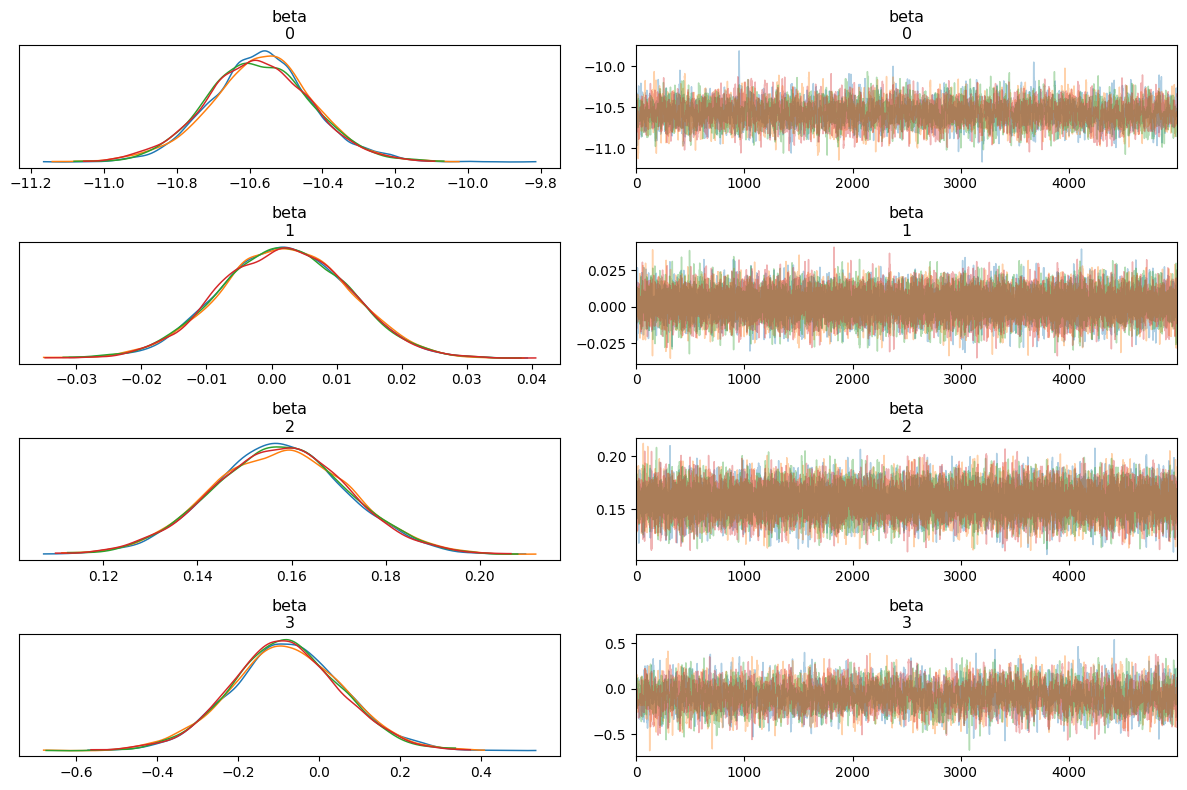

: 

In [ ]:
az.plot_trace(poi_glm1_data, var_names=["beta"], compact=False)
plt.tight_layout() 
plt.show()

In [ ]:
# Input data
glm2_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X_INTERACTIONS.shape[1],
    "Y": Y,
    "D": D,
    "X": X_INTERACTIONS,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}

# Sample
glm2_fit = glm1.sample(data=glm2_data, chains=4, parallel_chains=4, 
                             iter_warmup=1000, iter_sampling=5000,show_console=True)

# Convert to arviz data type
poi_glm2_data = az.from_cmdstanpy(glm2_fit)

23:15:07 - cmdstanpy - INFO - Chain [1] start processing
23:15:07 - cmdstanpy - INFO - Chain [2] start processing
23:15:07 - cmdstanpy - INFO - Chain [3] start processing
23:15:07 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5000
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpykli4vm8/3ep1bumf.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 7894
Chain [1] output


23:22:35 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 55.59 seconds (Warm-up)
Chain [4] 392.69 seconds (Sampling)
Chain [4] 448.28 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain 

23:22:37 - cmdstanpy - INFO - Chain [2] done processing


...

Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 58.227 seconds (Warm-up)
Chain [3] 392.203 seconds (Sampling)
Chain [3] 450.43 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chai

23:22:39 - cmdstanpy - INFO - Chain [1] done processing
23:22:39 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)

Chain [1] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 60.02 seconds (Warm-up)
Chain [1] 392.088 seconds (Sampling)
Chain [1] 452.108 seconds (Total)
Chain [1] 
Chain [1] 


23:22:40 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 4985 iterations at max treedepth (99.7%)
	Chain 2 had 4998 iterations at max treedepth (100.0%)
	Chain 3 had 4984 iterations at max treedepth (99.7%)
	Chain 4 had 4978 iterations at max treedepth (99.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


: 

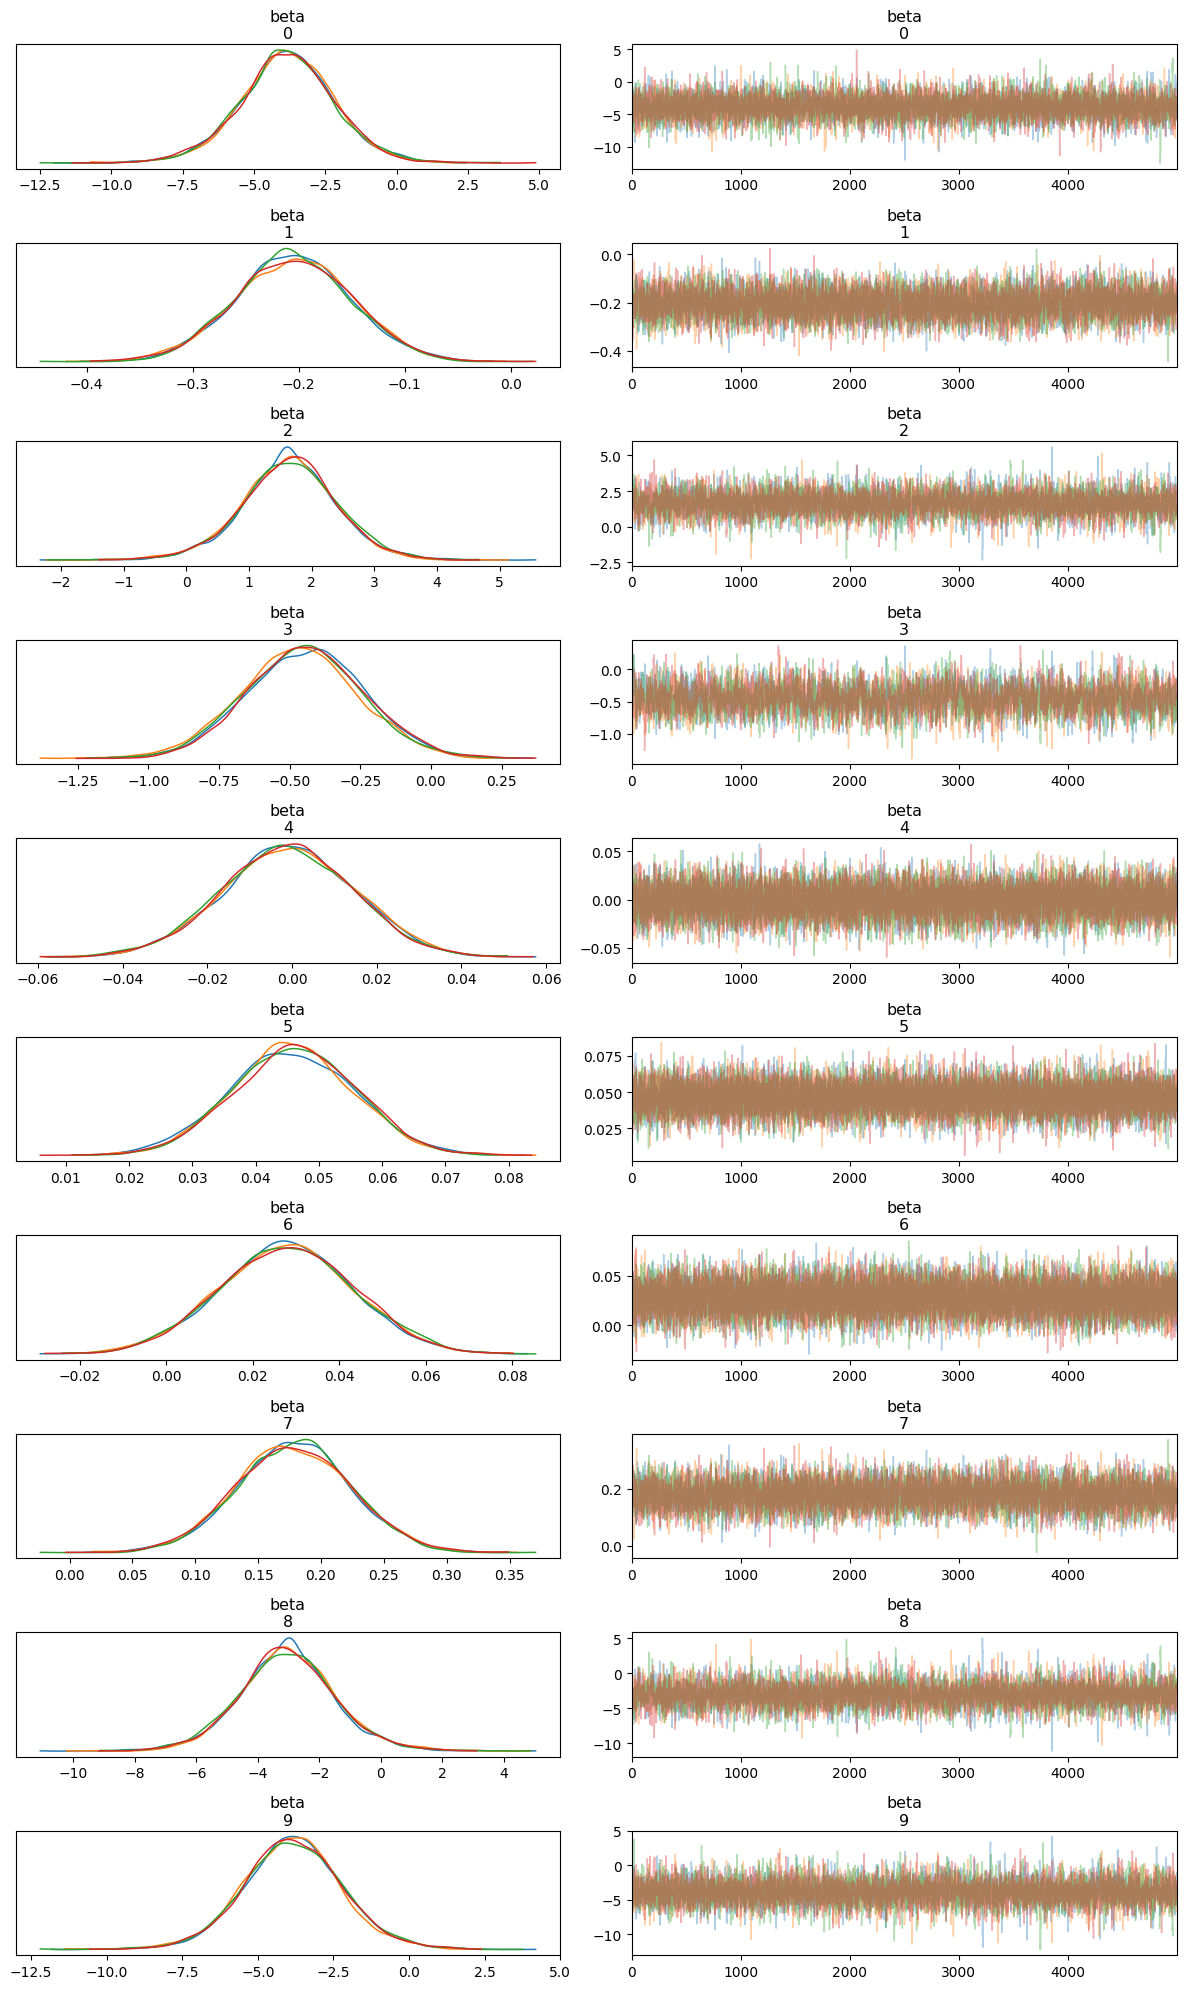

: 

In [ ]:
az.plot_trace(poi_glm2_data, var_names=["beta"], compact=False)
plt.tight_layout()
plt.show()

In [ ]:
# Input data
glm3_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X_ONLY_INTERACTIONS.shape[1],
    "Y": Y,
    "D": D,
    "X": X_ONLY_INTERACTIONS,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}

# Sample
glm3_fit = glm1.sample(data=glm3_data, chains=4, parallel_chains=4, 
                             iter_warmup=1000, iter_sampling=5000,show_console=True)

# Convert to arviz data type
poi_glm3_data = az.from_cmdstanpy(glm3_fit)

23:24:40 - cmdstanpy - INFO - Chain [1] start processing
23:24:40 - cmdstanpy - INFO - Chain [2] start processing
23:24:40 - cmdstanpy - INFO - Chain [3] start processing
23:24:40 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5000
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpykli4vm8/cb6se43z.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 90318
Chain [1] output

23:25:30 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 7.627 seconds (Warm-up)
Chain [3]                42.729 seconds (Sampling)
Chain [3]                50.356 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 5700 / 6000 [ 95%]  (Sampling)
Chain [2] Iteration: 5400 / 6000 [ 90%]  (Sampling)
Chain [4] Iteration: 5700 / 6000 [ 95%]  (Sampling)
Chain [1] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [2] Iteration: 5500 / 6000 [ 91%]  (Sampling)
Chain [4] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [1] Iteration: 5900 / 6000 [ 98%]  (Sampling)
Chain [2] Iteration: 5600 / 6000 [ 93%]  (Sampling)
Chain [4] Iteration: 5900 / 6000 [ 98%]  (Sampling)


23:25:32 - cmdstanpy - INFO - Chain [1] done processing


...

23:25:33 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 7.853 seconds (Warm-up)
Chain [4] 44.805 seconds (Sampling)
Chain [4] 52.658 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain 

23:25:34 - cmdstanpy - INFO - Chain [2] done processing
23:25:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ab_glm.stan', line 65, column 12 to column 53)
Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
	Exception: poisson_lpmf: Rate parameter is -nan, but must be nonnegative! (in 'ab_glm.stan', line 40, column 8 to column 45)
Exce

Chain [2] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 11.981 seconds (Warm-up)
Chain [2] 41.717 seconds (Sampling)
Chain [2] 53.698 seconds (Total)
Chain [2] 
Chain [2] 


: 

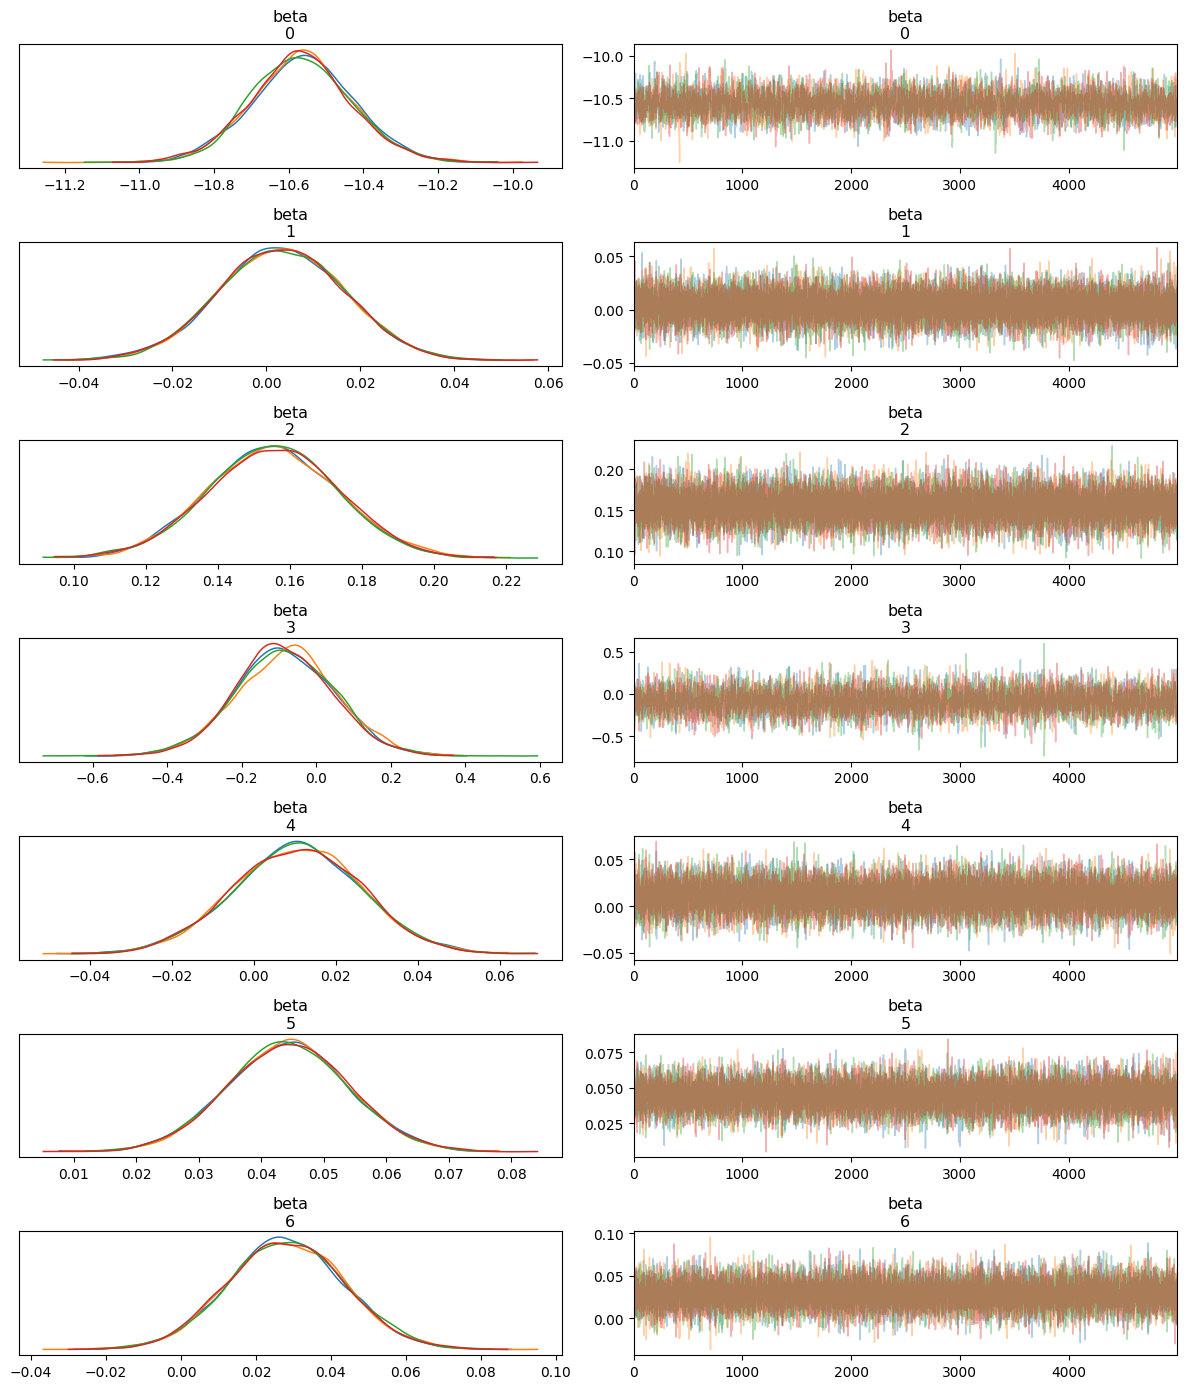

: 

In [ ]:
az.plot_trace(poi_glm3_data, var_names=["beta"], compact=False)
plt.tight_layout()
plt.show()

In [ ]:
#check MCMC chain

#check MCMC chain
print("divergence",np.sum(poi_glm1_data.sample_stats.diverging))
#check MCMC chain
print("divergence",np.sum(poi_glm2_data.sample_stats.diverging))
#no divergence!!!!
#check MCMC chain
print("divergence",np.sum(poi_glm3_data.sample_stats.diverging))
#no divergence!!!!
#no divergence!!!!

divergence <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence <xarray.DataArray 'diverging' ()> Size: 8B
array(0)
divergence <xarray.DataArray 'diverging' ()> Size: 8B
array(0)


: 

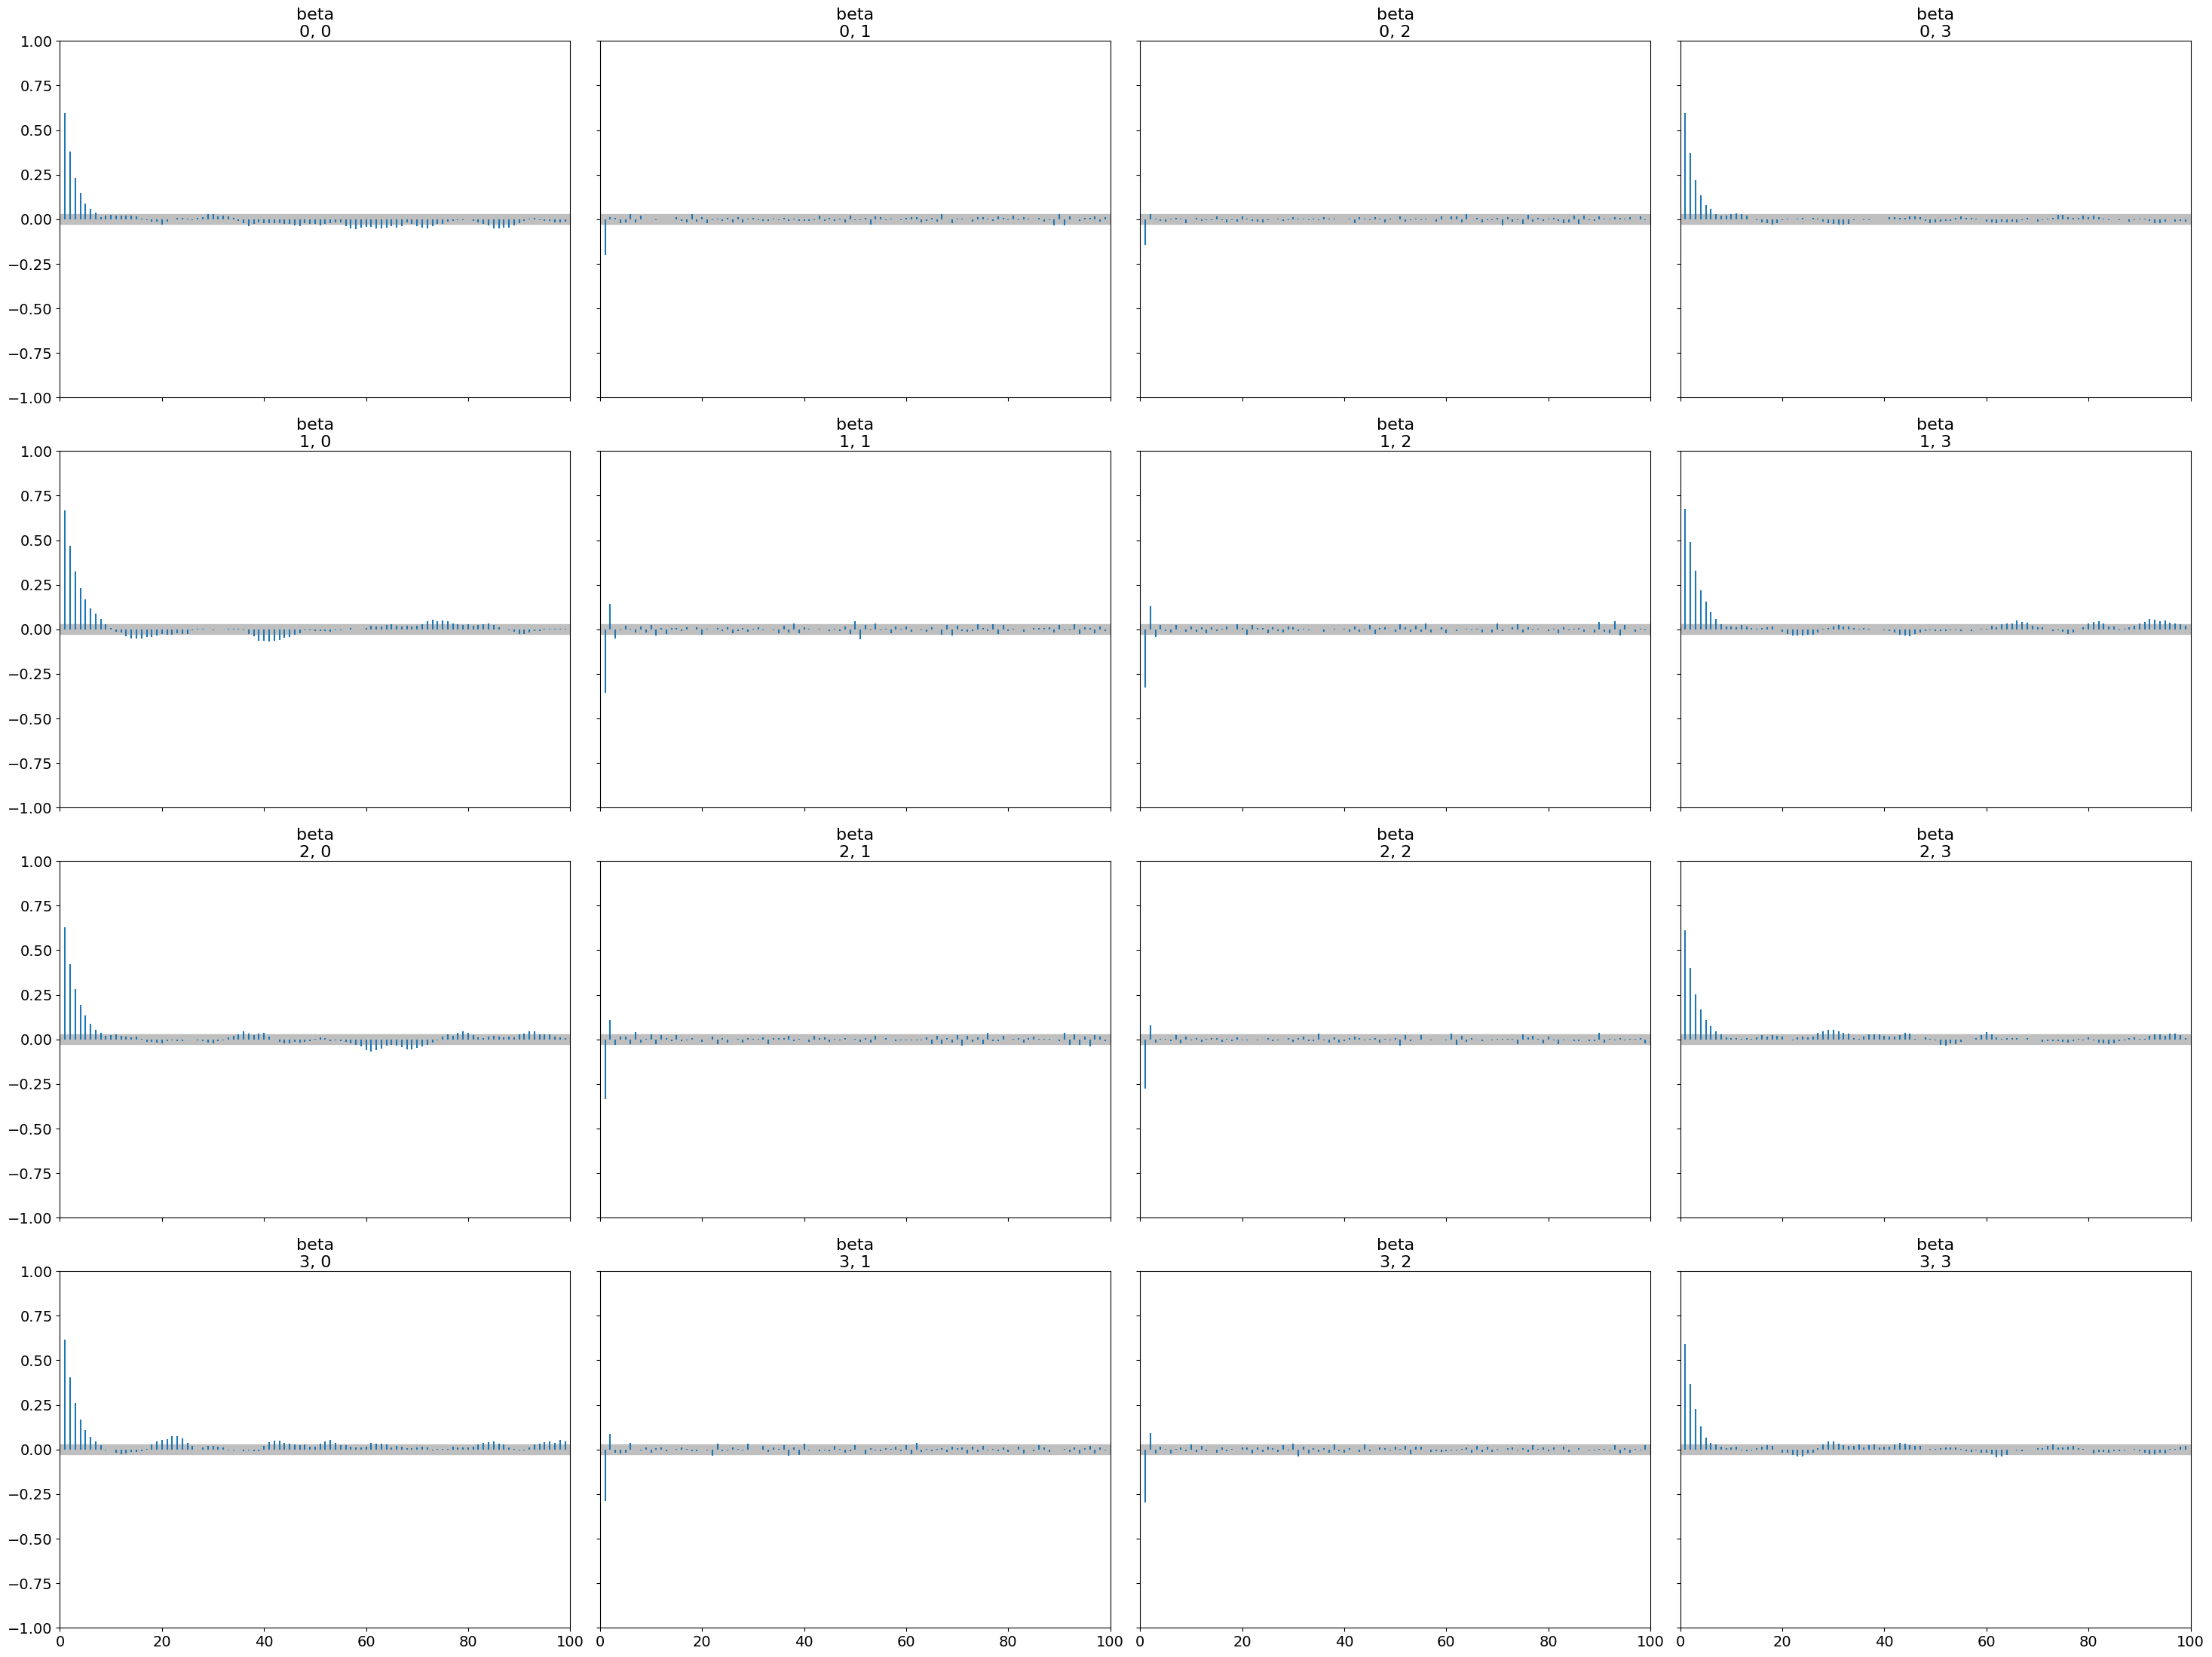

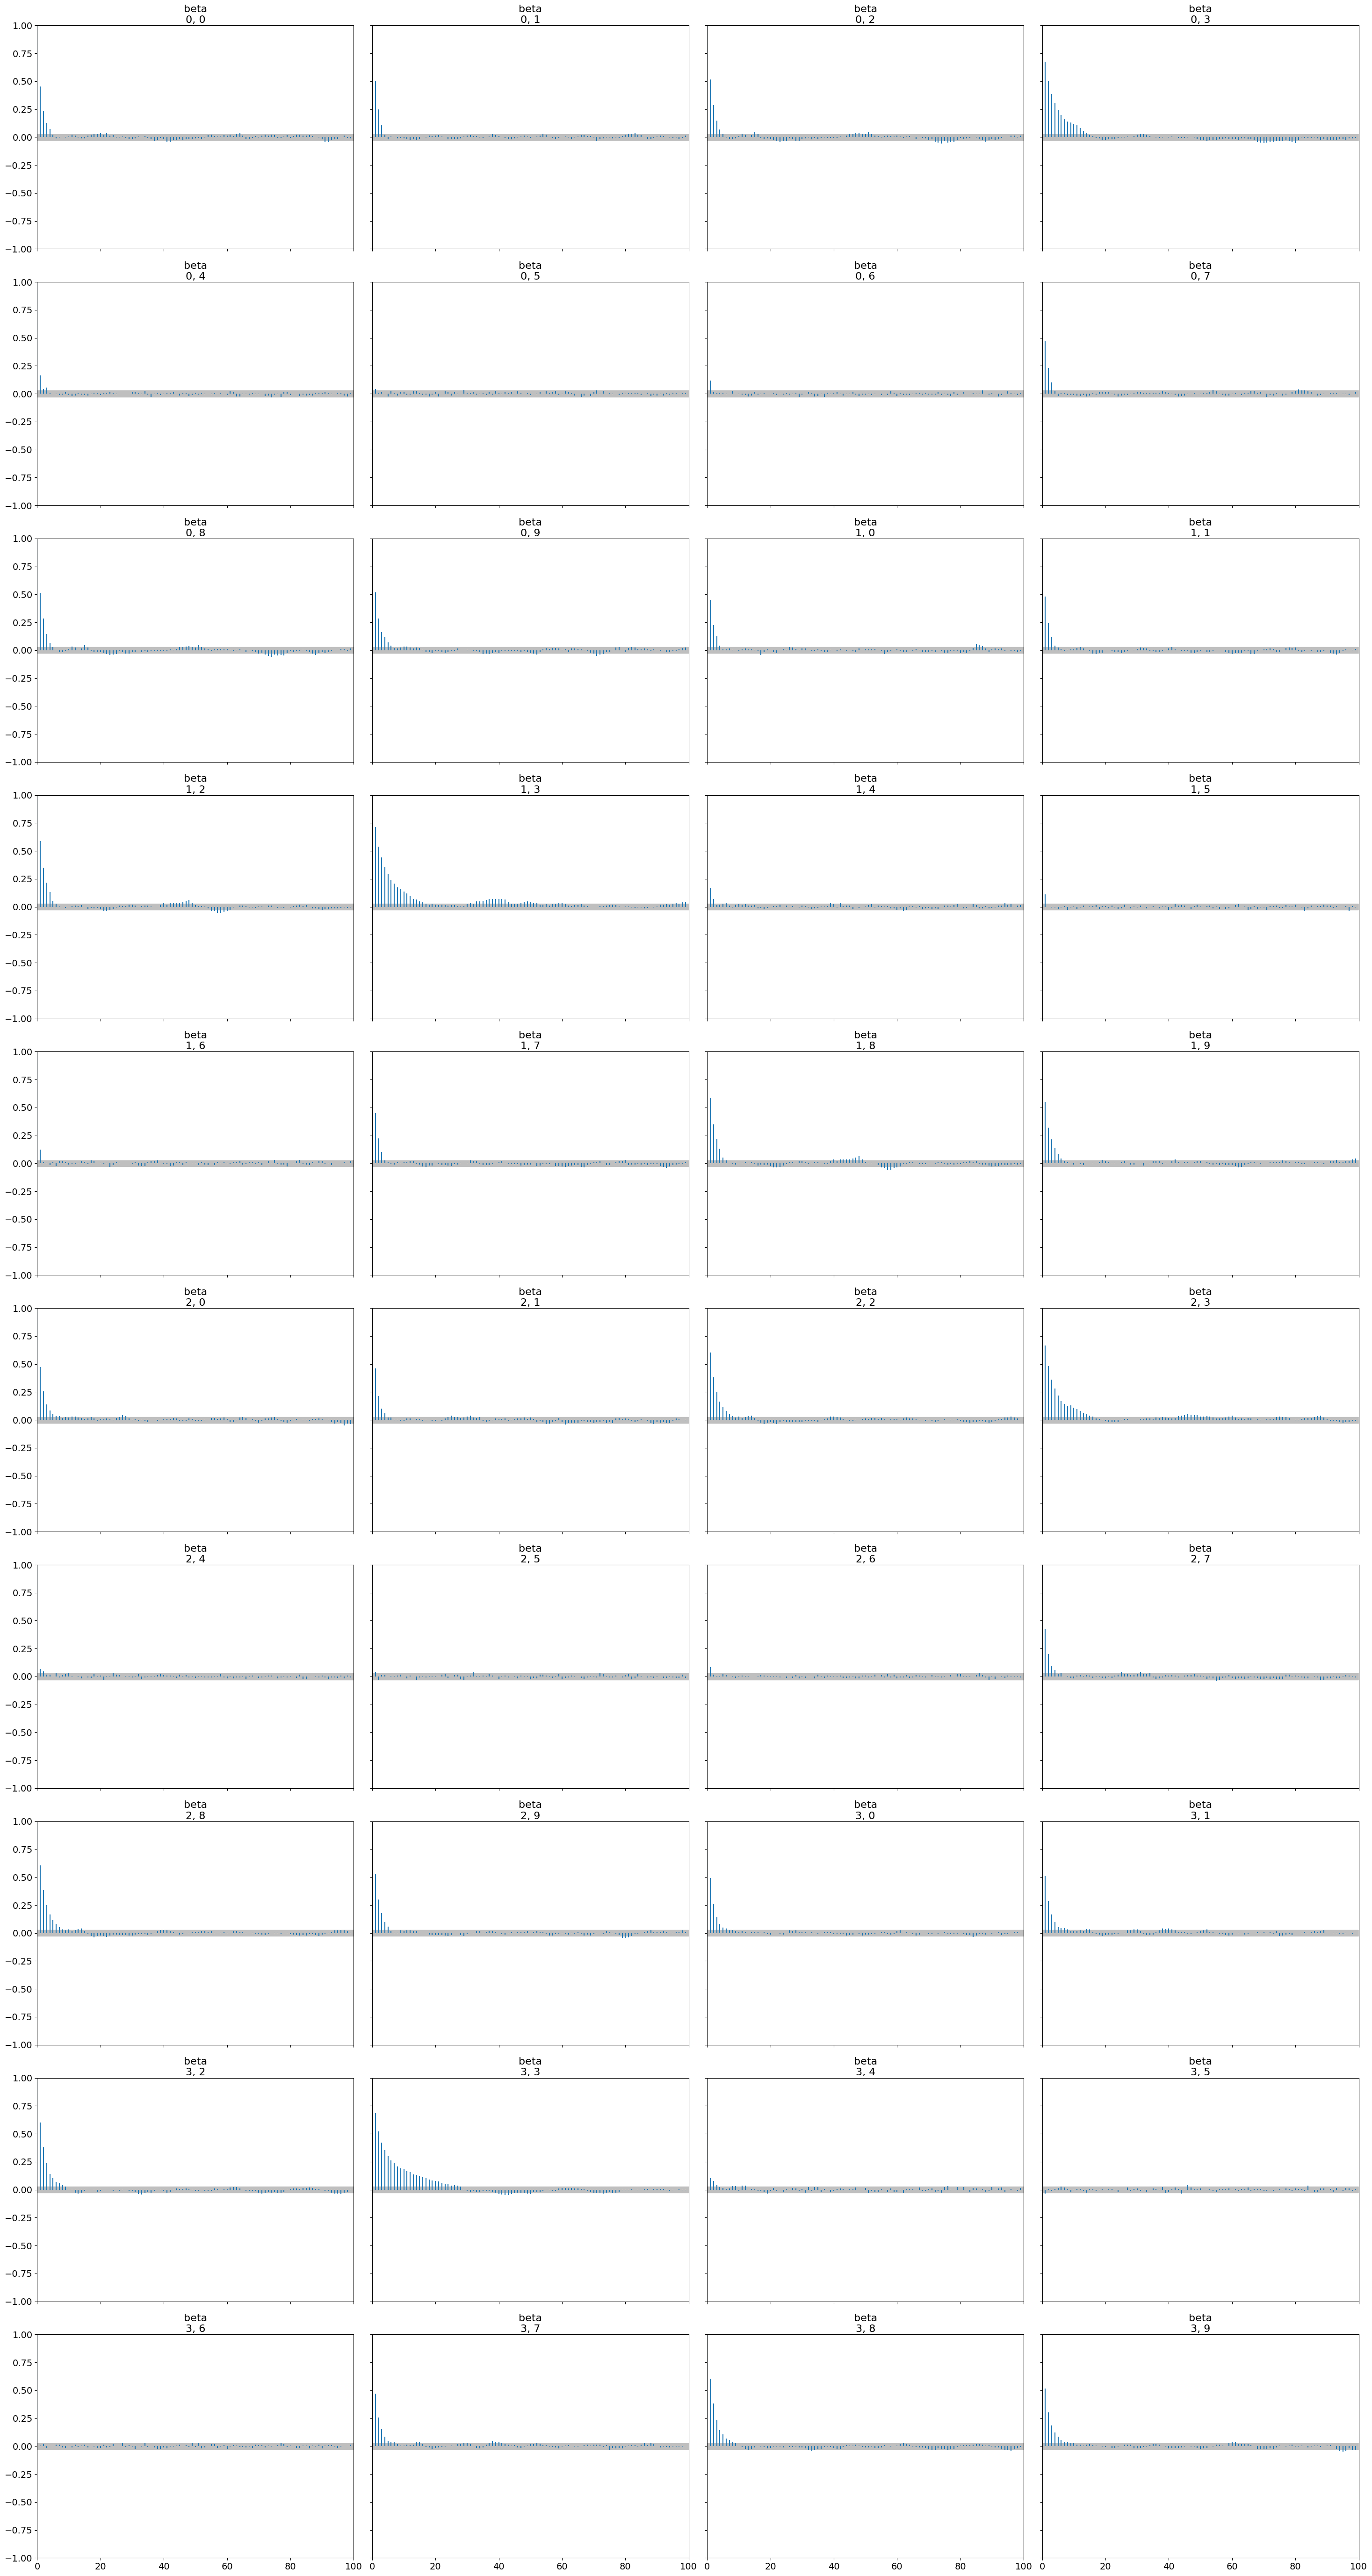

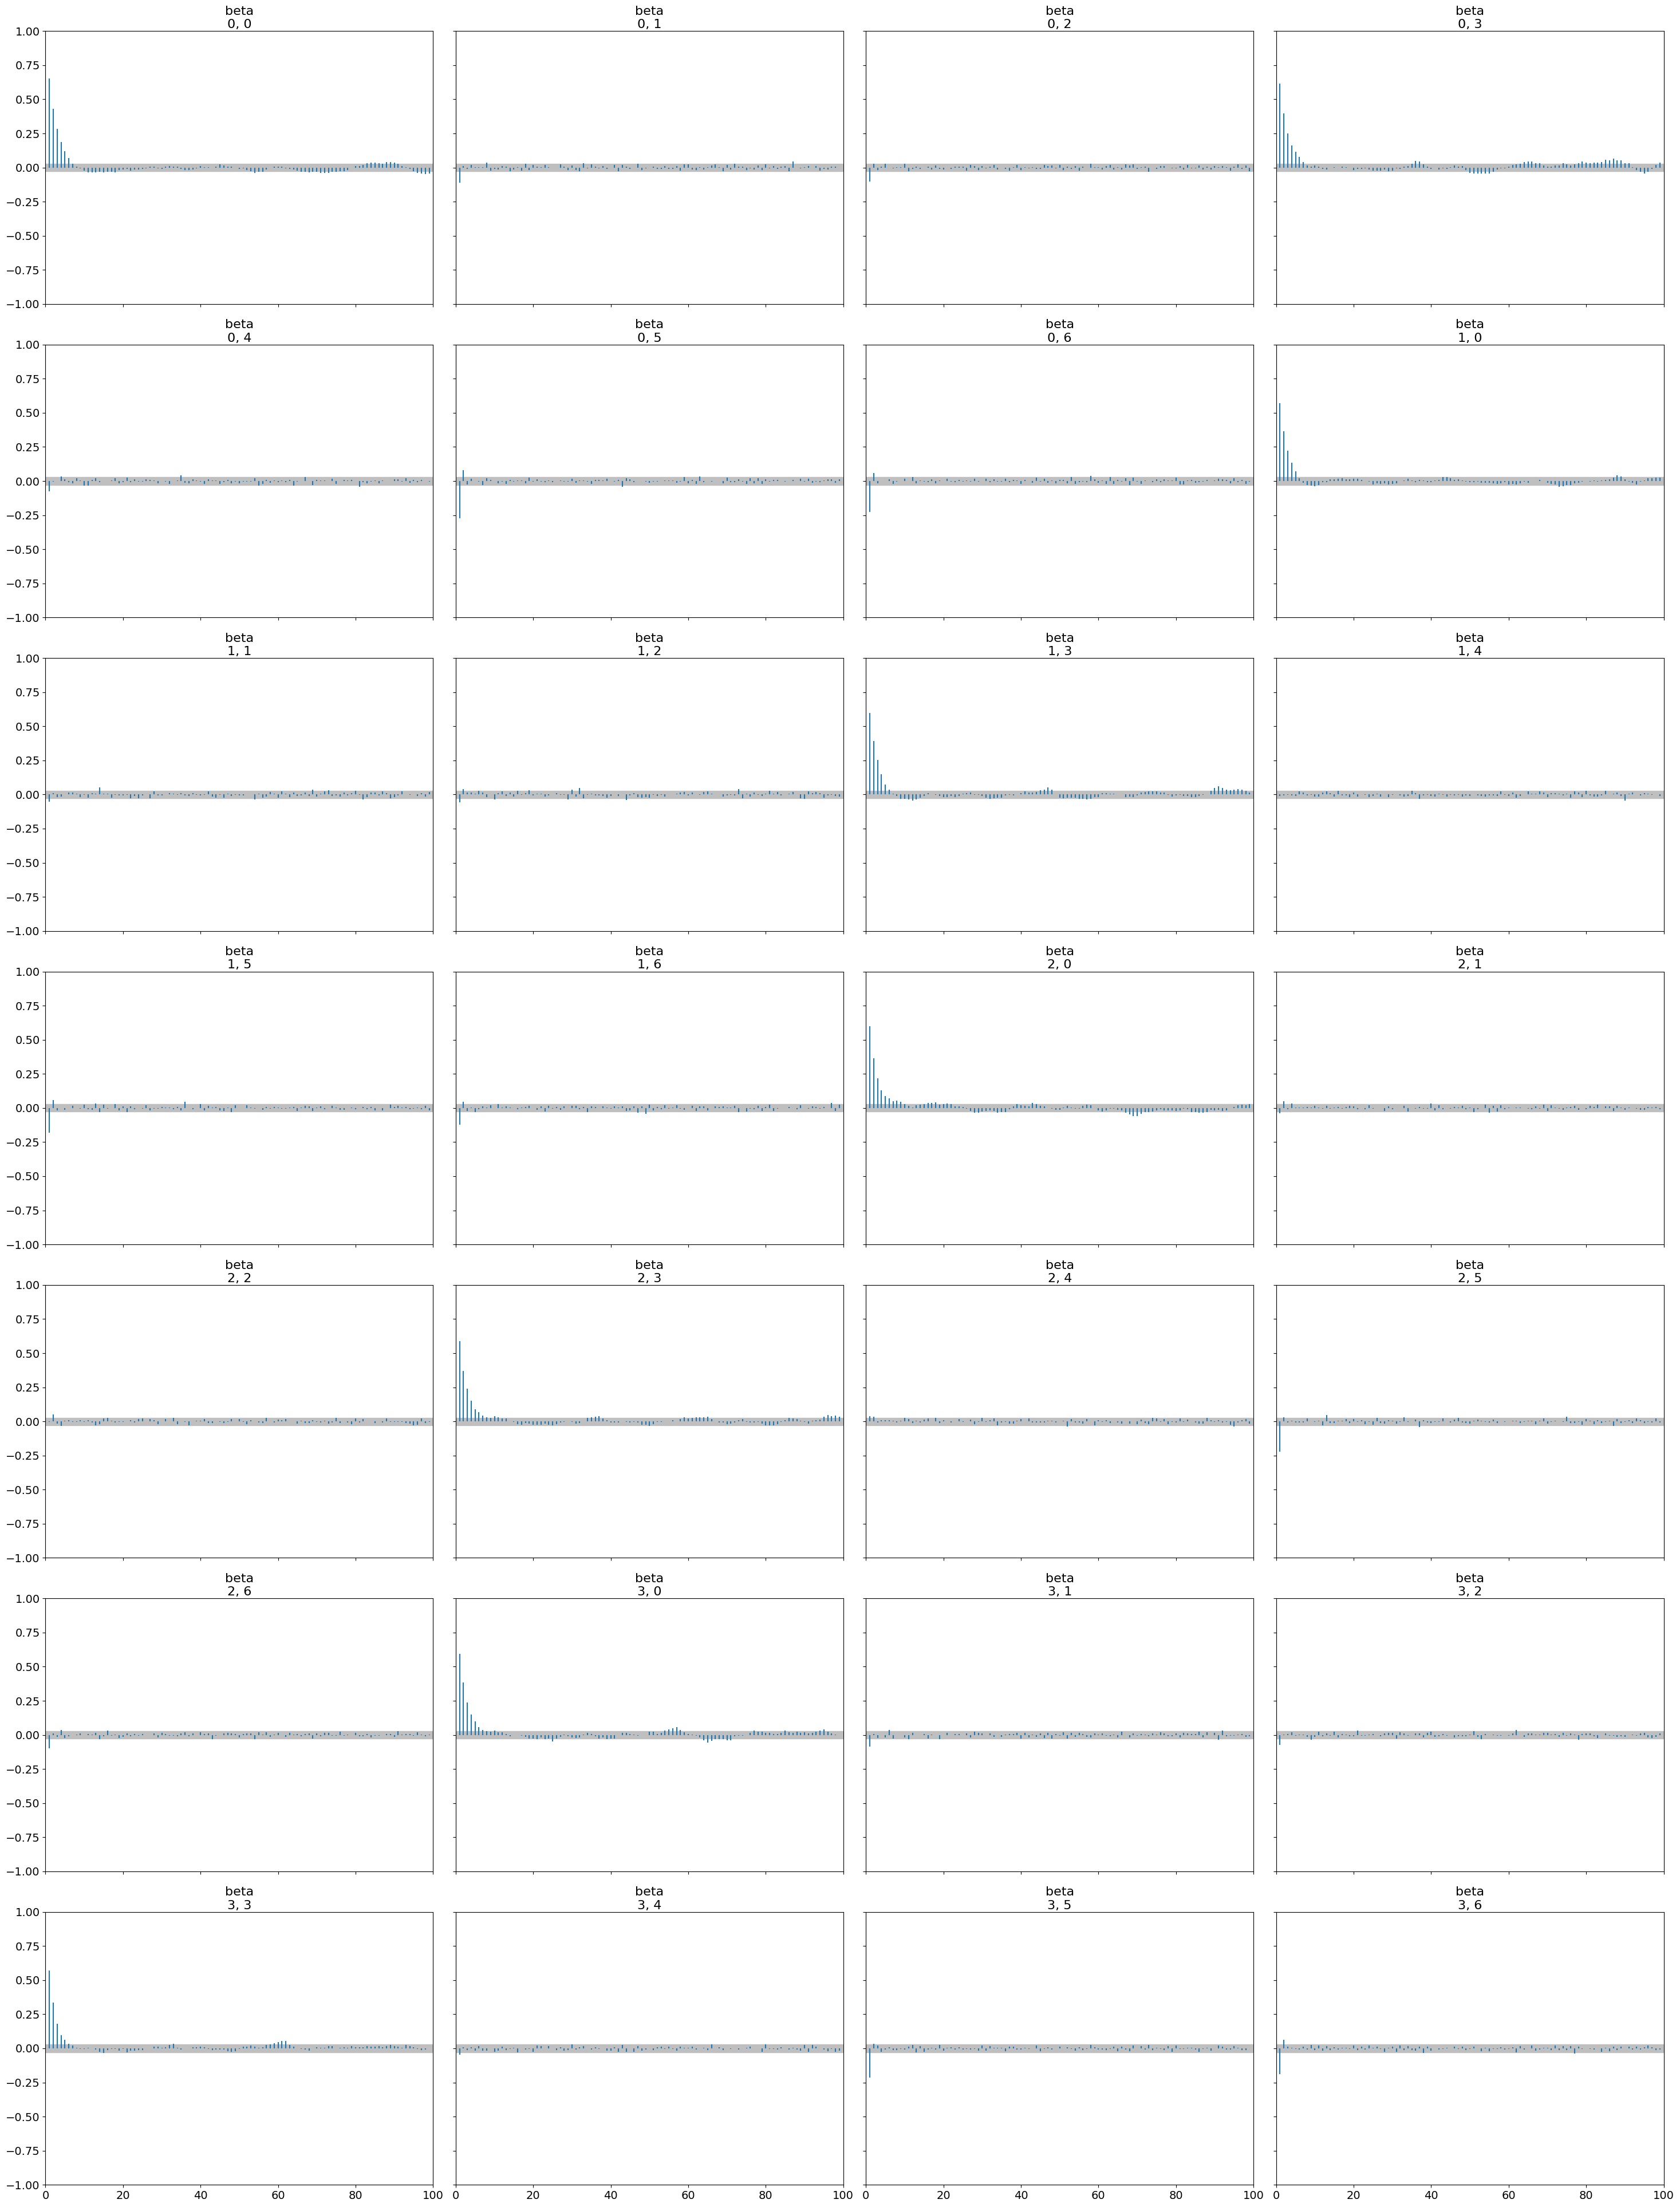

: 

In [ ]:
az.plot_autocorr(poi_glm1_data, var_names=["beta"])
plt.tight_layout()
plt.show() 
az.plot_autocorr(poi_glm2_data, var_names=["beta"])
plt.tight_layout()
plt.show()  
az.plot_autocorr(poi_glm3_data, var_names=["beta"])
plt.tight_layout()
plt.show()      

In [ ]:
glm1_fit.summary()


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68879.000000,0.055067,4.538850,4.452250,68870.900000,68879.400000,68885.800000,6845.65,11438.30,34.1543,1.00110
beta[1],-10.570900,0.002210,0.144009,0.139063,-10.806300,-10.571700,-10.333600,4270.71,5908.64,21.3074,1.00082
beta[2],0.001906,0.000051,0.009752,0.009887,-0.014051,0.001912,0.017775,37286.50,15299.70,186.0300,1.00009
beta[3],0.157533,0.000080,0.014381,0.014364,0.133811,0.157580,0.181324,32611.30,14999.90,162.7040,1.00019
beta[4],-0.081414,0.002088,0.138163,0.134540,-0.306738,-0.082706,0.146241,4398.10,7012.90,21.9430,1.00045
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.541960,0.001042,0.136981,0.094753,-2.822930,-2.494850,-2.421850,20197.60,16542.40,100.7700,1.00040
log_lik[375],-3.192800,0.002758,0.396175,0.388210,-3.918130,-3.146560,-2.627450,21424.80,16518.80,106.8920,1.00060
log_lik[376],-2.177930,0.001014,0.148043,0.148895,-2.428210,-2.174440,-1.939980,21424.80,16518.80,106.8920,1.00065
log_lik[377],-1.401870,0.000551,0.080131,0.080214,-1.541060,-1.397670,-1.277300,21424.80,16518.80,106.8920,1.00064


: 

In [ ]:
glm2_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68895.800000,0.060311,4.917510,4.899990,68887.200000,68896.100000,68903.300000,6778.76,11006.20,4.31866,1.000070
beta[1],-3.847720,0.021500,1.687420,1.567310,-6.629300,-3.839250,-1.107040,6406.47,8616.11,4.08148,1.000300
beta[2],-0.205043,0.000667,0.054418,0.054197,-0.294202,-0.205225,-0.115131,6663.78,10202.50,4.24540,1.000530
beta[3],1.640280,0.010883,0.772017,0.717803,0.351935,1.648000,2.877940,5181.60,6550.02,3.30113,1.000520
beta[4],-0.449882,0.004506,0.209106,0.206293,-0.792209,-0.449574,-0.105347,2188.05,3954.26,1.39397,1.002650
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.552760,0.001305,0.155840,0.099543,-2.870750,-2.497220,-2.421710,15326.60,15105.60,9.76437,1.000050
log_lik[375],-3.203670,0.003471,0.438419,0.426467,-4.008790,-3.147790,-2.589110,16250.30,14983.60,10.35280,0.999947
log_lik[376],-2.179050,0.001282,0.163195,0.163106,-2.454520,-2.174900,-1.917480,16248.50,14983.60,10.35170,0.999947
log_lik[377],-1.402970,0.000695,0.088401,0.087936,-1.556590,-1.397920,-1.266470,16248.50,14983.60,10.35170,0.999947


: 

In [ ]:
glm3_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68886.300000,0.056198,4.754390,4.685020,68877.900000,68886.700000,68893.500000,7204.40,11749.90,41.5927,1.00029
beta[1],-10.564800,0.001956,0.135591,0.131729,-10.785200,-10.566000,-10.339400,4816.00,6272.77,27.8039,1.00041
beta[2],0.003272,0.000089,0.013352,0.013483,-0.018602,0.003222,0.025163,22633.10,15641.30,130.6660,1.00008
beta[3],0.155246,0.000127,0.018159,0.018114,0.125424,0.155217,0.185153,20532.70,15406.10,118.5400,1.00010
beta[4],-0.084560,0.001910,0.134103,0.131684,-0.304516,-0.086141,0.134145,4927.05,6734.55,28.4450,1.00069
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.485870,0.000792,0.091869,0.040766,-2.670290,-2.450960,-2.421230,14277.70,15604.10,82.4288,1.00026
log_lik[375],-2.921880,0.002510,0.349477,0.332100,-3.574080,-2.872810,-2.449320,19751.00,15932.50,114.0270,1.00009
log_lik[376],-2.064910,0.001085,0.152534,0.151146,-2.322780,-2.062510,-1.820170,19765.20,15932.50,114.1090,1.00005
log_lik[377],-1.342550,0.000561,0.078788,0.077741,-1.480020,-1.338590,-1.221240,19765.20,15932.50,114.1090,1.00005


: 

array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

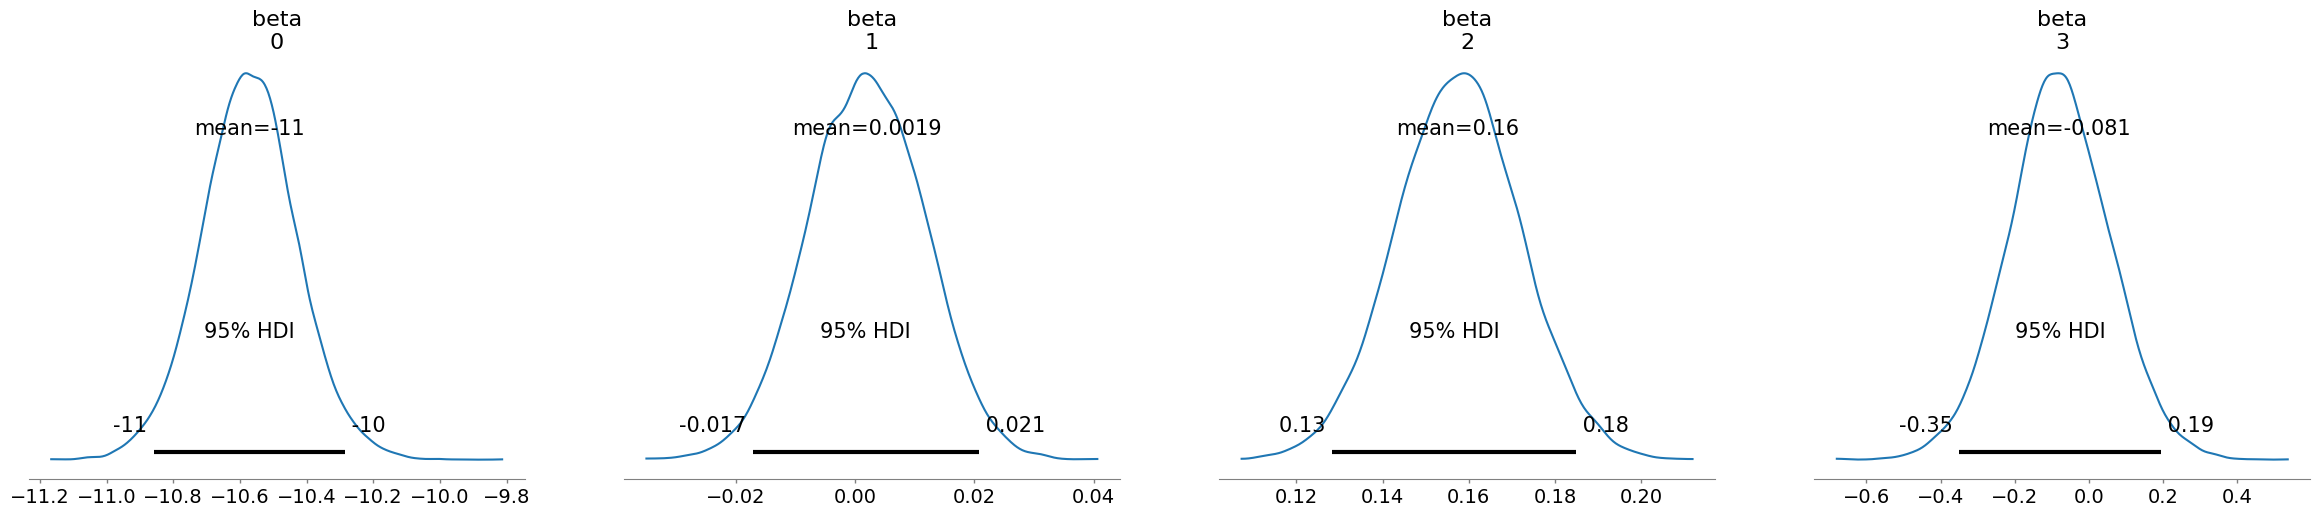

: 

In [ ]:
#plot posterior for beta
az.plot_posterior(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)

array([[<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'beta\n5'}>],
       [<Axes: title={'center': 'beta\n6'}>,
        <Axes: title={'center': 'beta\n7'}>,
        <Axes: title={'center': 'beta\n8'}>],
       [<Axes: title={'center': 'beta\n9'}>, <Axes: >, <Axes: >]],
      dtype=object)

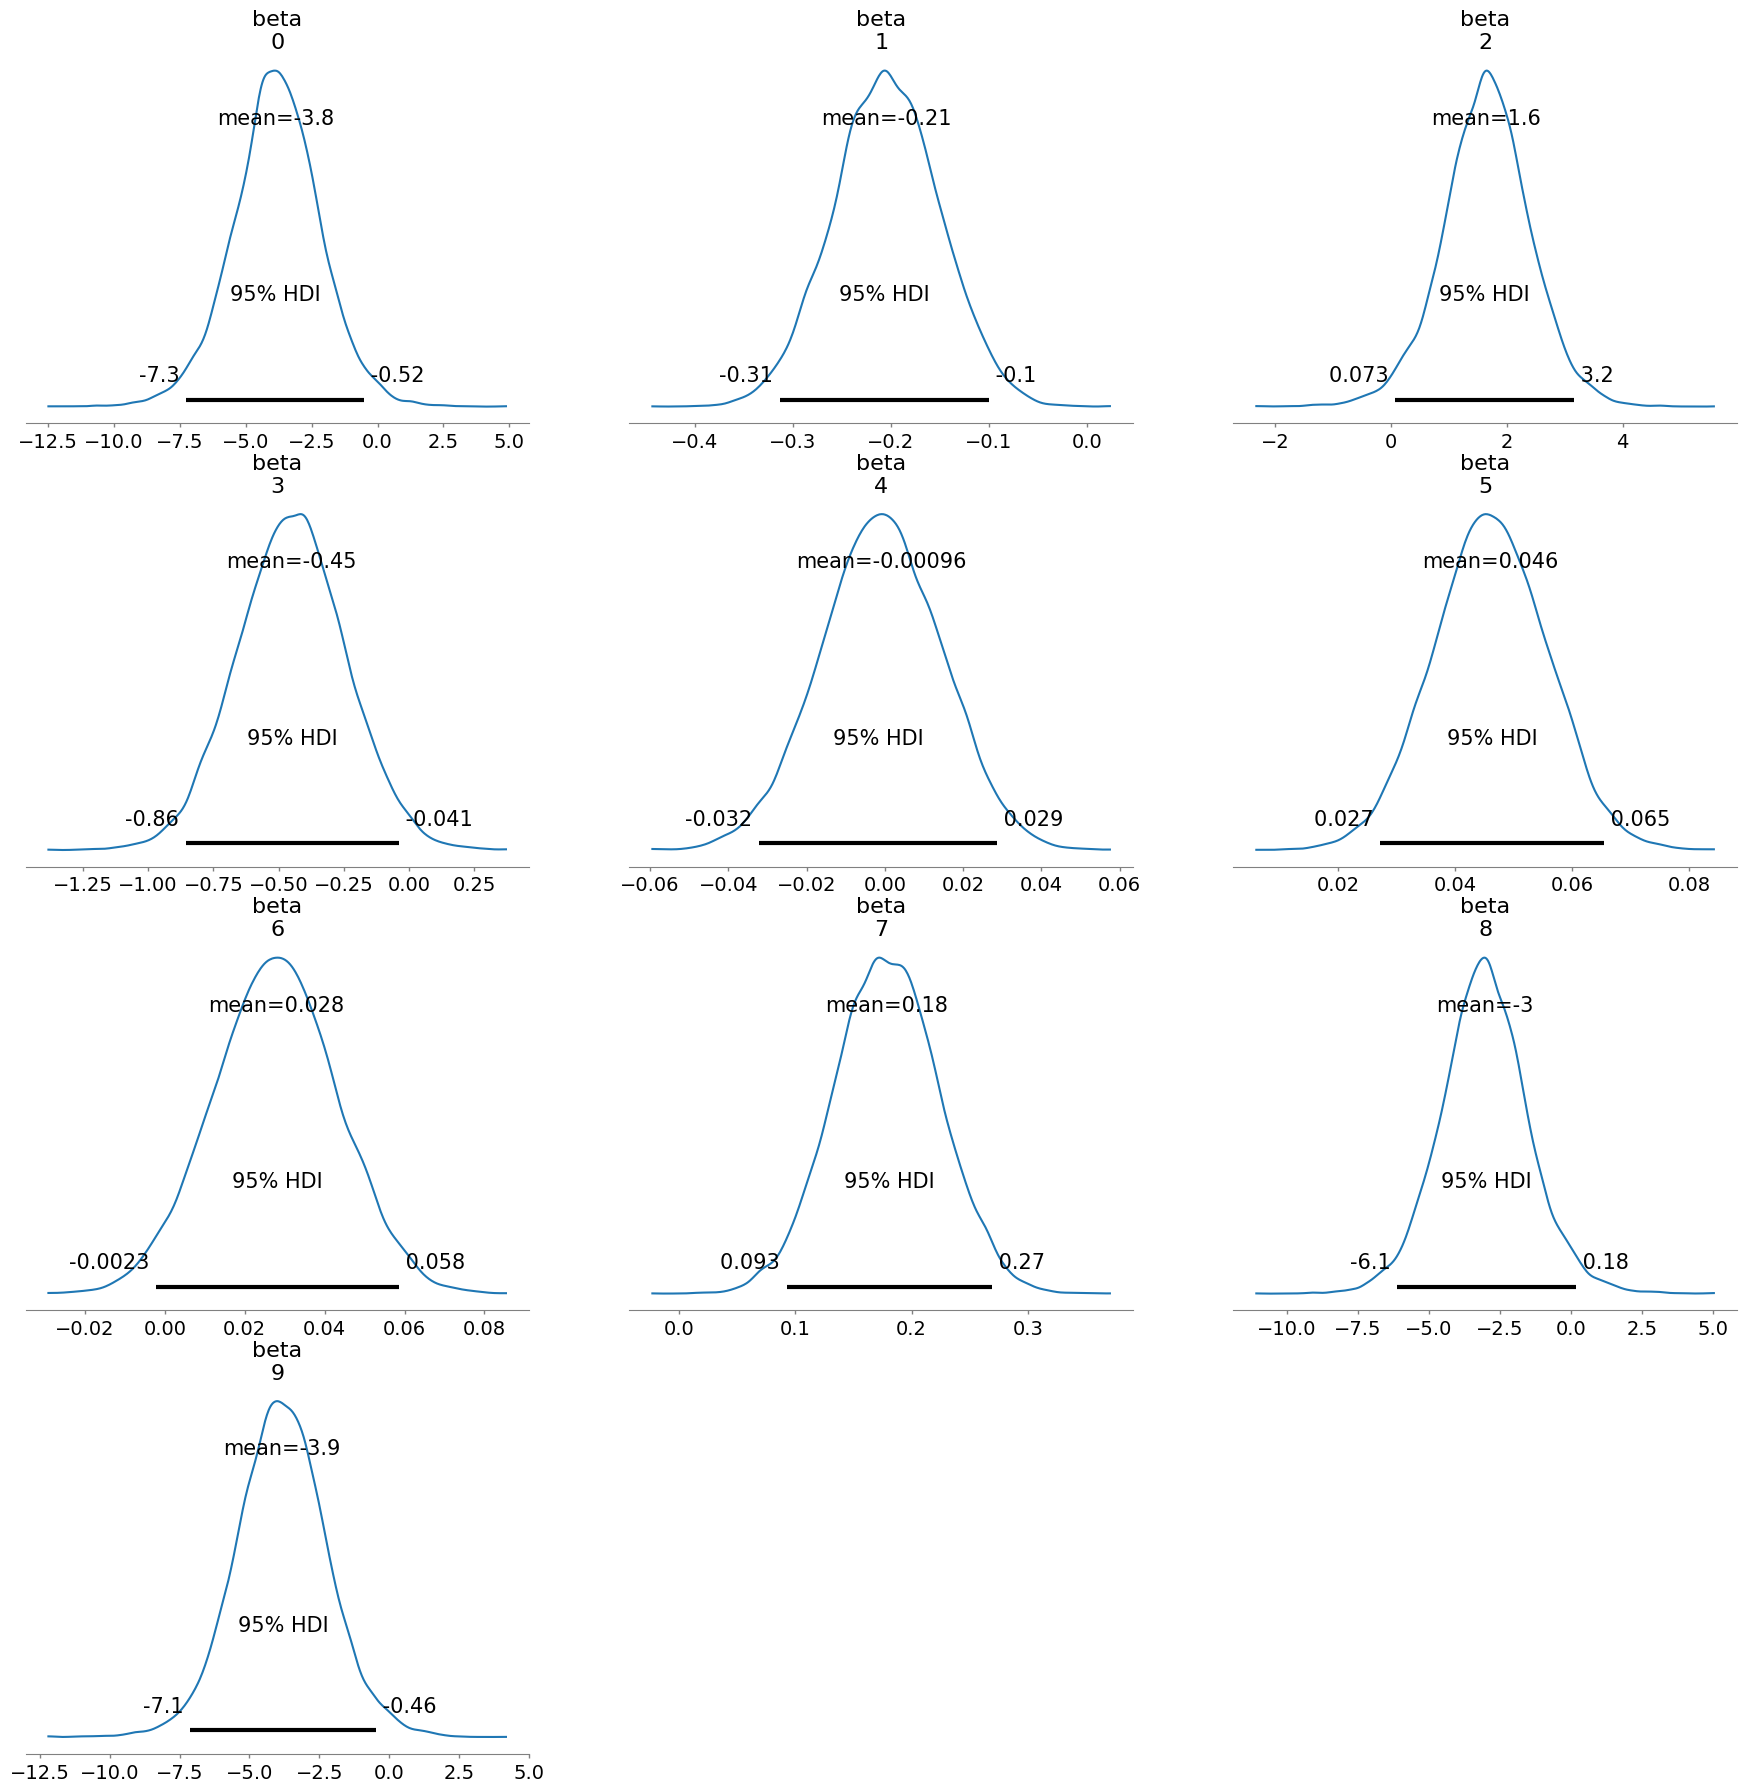

: 

In [ ]:
#plot posterior for beta
az.plot_posterior(poi_glm2_data, var_names=["beta"], hdi_prob=0.95)

array([[<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'beta\n5'}>],
       [<Axes: title={'center': 'beta\n6'}>, <Axes: >, <Axes: >]],
      dtype=object)

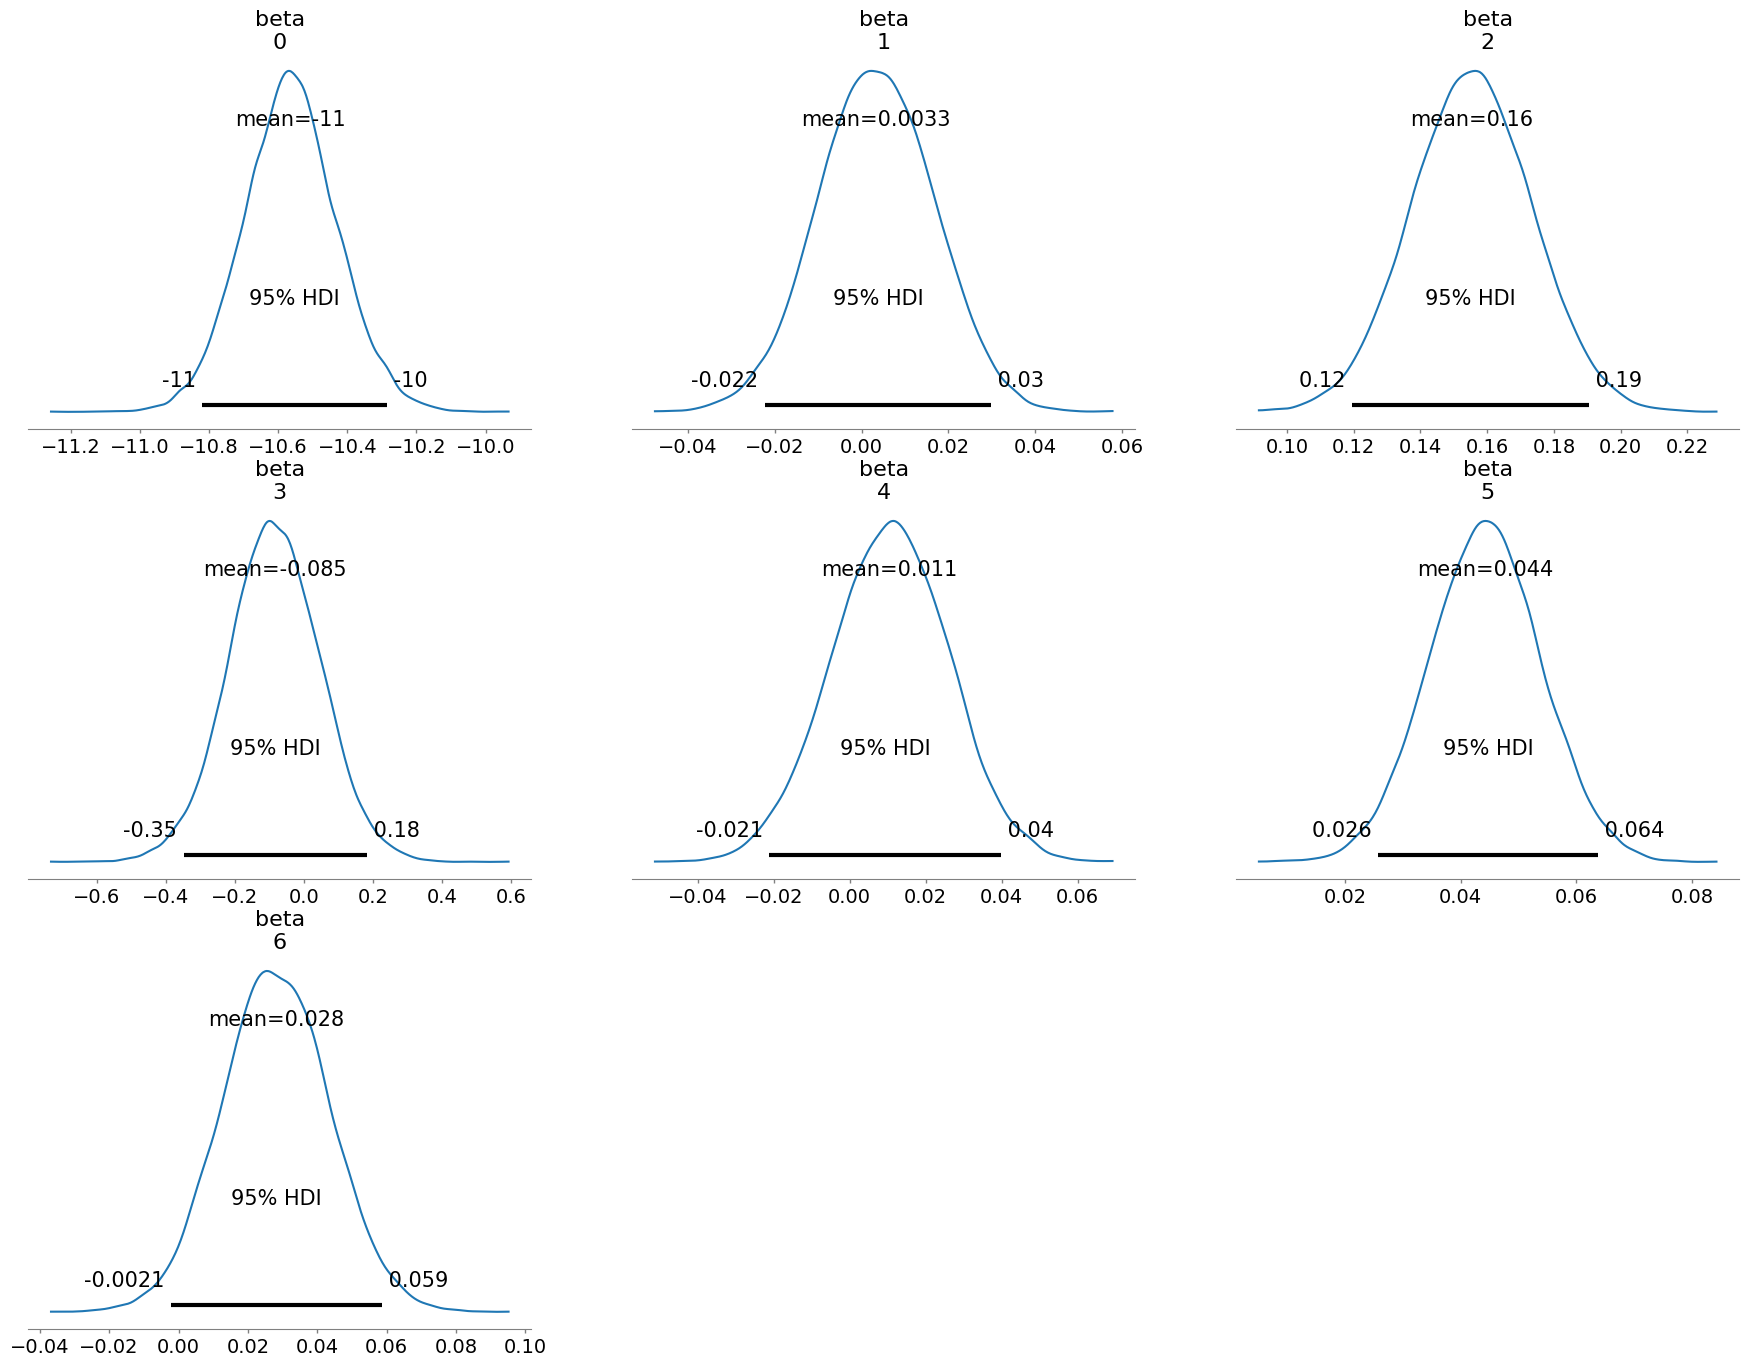

: 

In [ ]:
#plot posterior for beta
az.plot_posterior(poi_glm3_data, var_names=["beta"], hdi_prob=0.95)

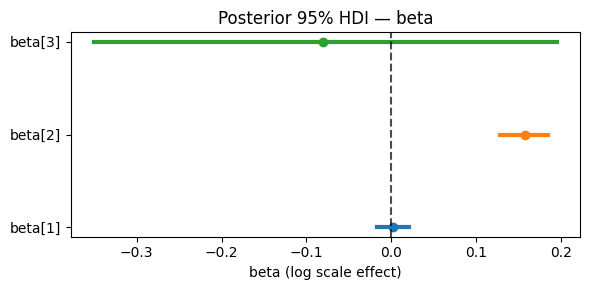

: 

In [ ]:
sum_beta = az.summary(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)

names = sum_beta.index.to_list()[1:]
mean  = sum_beta["mean"].values[1:]
low   = sum_beta["hdi_2.5%"].values[1:]
high  = sum_beta["hdi_97.5%"].values[1:]
y = np.arange(len(names))

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

plt.figure(figsize=(6, 3))
for i in range(len(names)):
    plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
    plt.plot(mean[i], y[i], "o", color=colors[i])

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, names)
plt.xlabel("beta (log scale effect)")
plt.title("Posterior 95% HDI — beta")
plt.tight_layout()
plt.show()

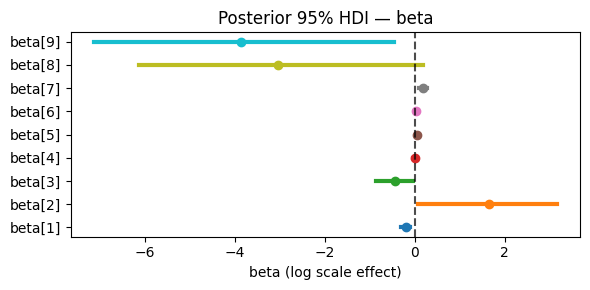

: 

In [ ]:
sum_beta = az.summary(poi_glm2_data, var_names=["beta"], hdi_prob=0.95)

names = sum_beta.index.to_list()[1:]
mean  = sum_beta["mean"].values[1:]
low   = sum_beta["hdi_2.5%"].values[1:]
high  = sum_beta["hdi_97.5%"].values[1:]
y = np.arange(len(names))

# Generate colors based on array length
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

plt.figure(figsize=(6, 3))
for i in range(len(names)):
    plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
    plt.plot(mean[i], y[i], "o", color=colors[i])

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, names)
plt.xlabel("beta (log scale effect)")
plt.title("Posterior 95% HDI — beta")
plt.tight_layout()
plt.show()

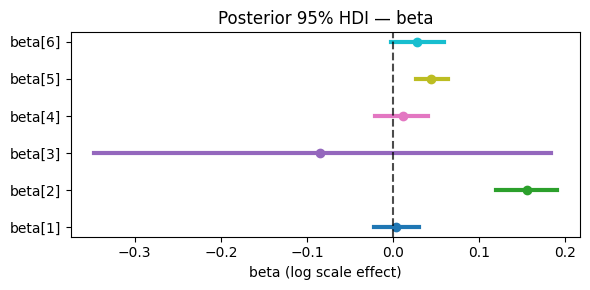

: 

In [ ]:
sum_beta = az.summary(poi_glm3_data, var_names=["beta"], hdi_prob=0.95)

names = sum_beta.index.to_list()[1:]
mean  = sum_beta["mean"].values[1:]
low   = sum_beta["hdi_2.5%"].values[1:]
high  = sum_beta["hdi_97.5%"].values[1:]
y = np.arange(len(names))

# Generate colors based on array length
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

plt.figure(figsize=(6, 3))
for i in range(len(names)):
    plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
    plt.plot(mean[i], y[i], "o", color=colors[i])

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, names)
plt.xlabel("beta (log scale effect)")
plt.title("Posterior 95% HDI — beta")
plt.tight_layout()
plt.show()

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Model 1 LOO: Computed from 20000 posterior samples and 378 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1609.79    83.35
p_loo      111.56        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      373   98.7%
   (0.70, 1]   (bad)         3    0.8%
   (1, Inf)   (very bad)    2    0.5%

Model 2 LOO: Computed from 20000 posterior samples and 378 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1599.20    79.90
p_loo      122.13        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      369   97.6%
   (0.70, 1]   (bad)         8    2.1%
   (1, Inf)   (very bad)    1    0.3%

Model 3 LOO: Computed from 20000 posterior samples and 378 observations log-likelihood matrix.

         Estimat

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


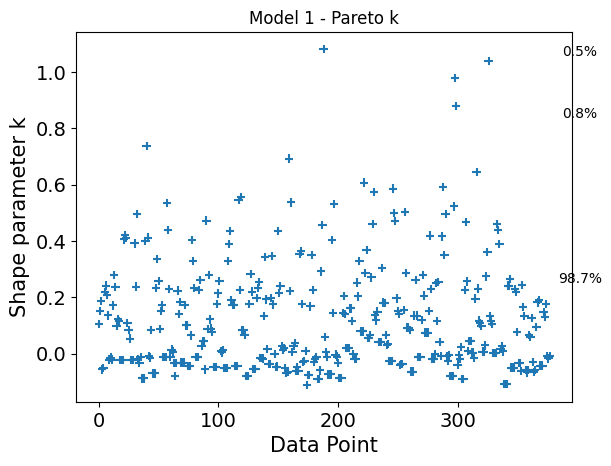

: 

In [ ]:
# ============================================================================
# 1. LOO-CV (PSIS-LOO) — THE GOLD STANDARD
# ============================================================================
loo1 = az.loo(poi_glm1_data)
loo2 = az.loo(poi_glm2_data)
loo3 = az.loo(poi_glm3_data)

print("Model 1 LOO:", loo1)
print("Model 2 LOO:", loo2)
print("Model 3 LOO:", loo3)

# Check Pareto k diagnostic (k > 0.7 = bad)
print("\nPareto k diagnostics:")
print("Model 1:", (poi_glm1_data.log_likelihood['log_lik'].values))
az.plot_khat(loo1, show_bins=True)
plt.title("Model 1 - Pareto k")
plt.show()

In [ ]:


waic1 = az.waic(poi_glm1_data)
waic2 = az.waic(poi_glm2_data)
waic3 = az.waic(poi_glm3_data)

print("Model 1 WAIC:", waic1)
print("Model 2 WAIC:", waic2)
print("Model 3 WAIC:", waic3)

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Model 1 WAIC: Computed from 20000 posterior samples and 378 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1607.08    83.07
p_waic      108.85        -

There has been a warning during the calculation. Please check the results.
Model 2 WAIC: Computed from 20000 posterior samples and 378 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1594.87    79.51
p_waic      117.80        -

There has been a warning during the calculation. Please check the results.
Model 3 WAIC: Computed from 20000 posterior samples and 378 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1600.55    81.43
p_waic      114.68        -

There has been a warning during the calculation. Please check the results.


/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


: 

/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



=== LOO COMPARISON ===
                   rank     elpd_loo       p_loo  elpd_diff    weight  \
full_interactions     0 -1599.203932  122.127582   0.000000  0.520354   
only_interactions     1 -1603.821619  117.952119   4.617687  0.012490   
baseline              2 -1609.793082  111.558761  10.589151  0.467156   

                          se        dse  warning scale  
full_interactions  79.903355   0.000000     True   log  
only_interactions  81.699647  11.275924     True   log  
baseline           83.345609  16.731454     True   log  


/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


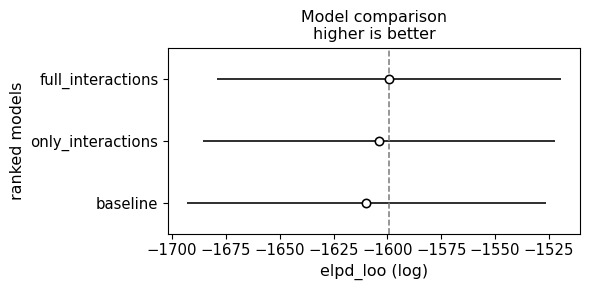

: 

In [ ]:
compare_dict = {
    "baseline": poi_glm1_data,
    "full_interactions": poi_glm2_data,
    "only_interactions": poi_glm3_data
}

comparison_loo = az.compare(compare_dict, ic="loo")
print("\n=== LOO COMPARISON ===")
print(comparison_loo)

az.plot_compare(comparison_loo, insample_dev=False)
plt.tight_layout()
plt.show()





/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(



=== WAIC COMPARISON ===
                   rank    elpd_waic      p_waic  elpd_diff  weight  \
full_interactions     0 -1594.872153  117.795804   0.000000  0.5317   
only_interactions     1 -1600.547307  114.677808   5.675154  0.0000   
baseline              2 -1607.083533  108.849211  12.211379  0.4683   

                          se        dse  warning scale  
full_interactions  79.509365   0.000000     True   log  
only_interactions  81.425086  11.181635     True   log  
baseline           83.069813  16.710340     True   log  


/home/ahbagheri/Projects/envs/.ML/lib/python3.12/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


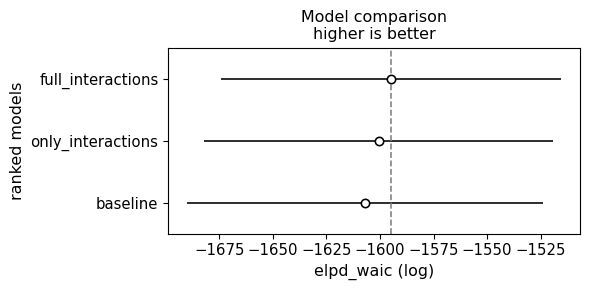

: 

In [ ]:
comparison_waic = az.compare(compare_dict, ic="waic")
print("\n=== WAIC COMPARISON ===")
print(comparison_waic)

az.plot_compare(comparison_waic, insample_dev=False)
plt.tight_layout()
plt.show()